# Demonstrations

## Setting up a Black Box Model

To demonstrate explainable AI, we first construct a black box model: An ensemble of neural networks to detect whether a written digit shows the number 1. The model is clearly too complex too be interpretable.

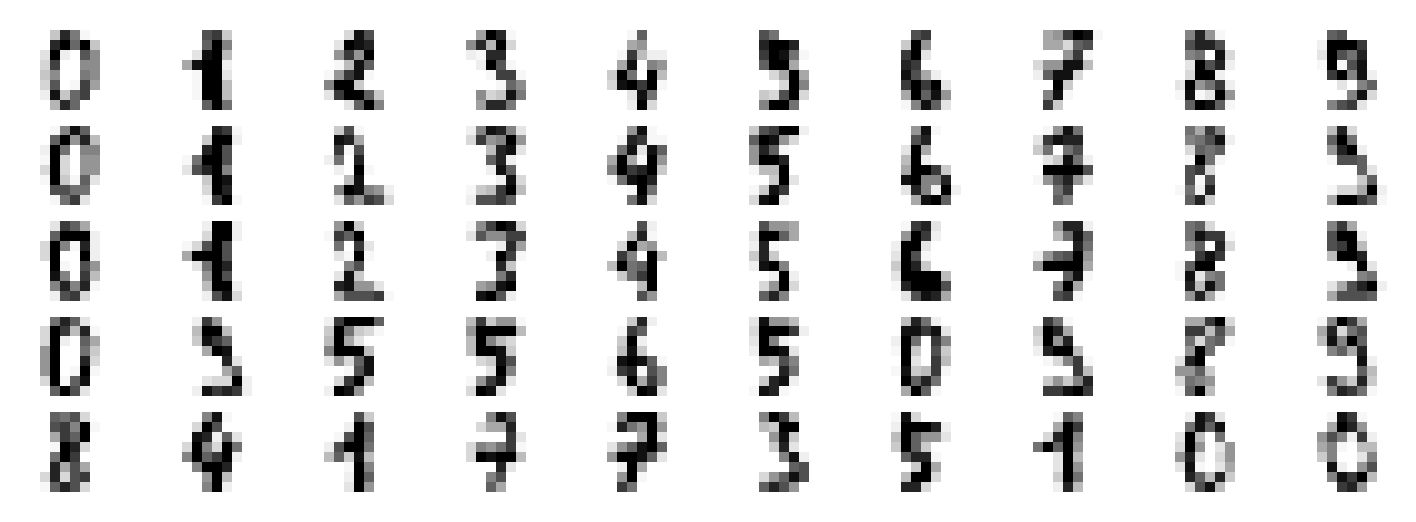

In [1]:
# Shows the digits.

import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
y = (y == 1)

fig, axs = plt.subplots(ncols=10, nrows=5, figsize=(6, 2))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(X[i].reshape(8, 8), cmap='Greys')
    ax.axis('off')

Validation Accuracy: 99.44%


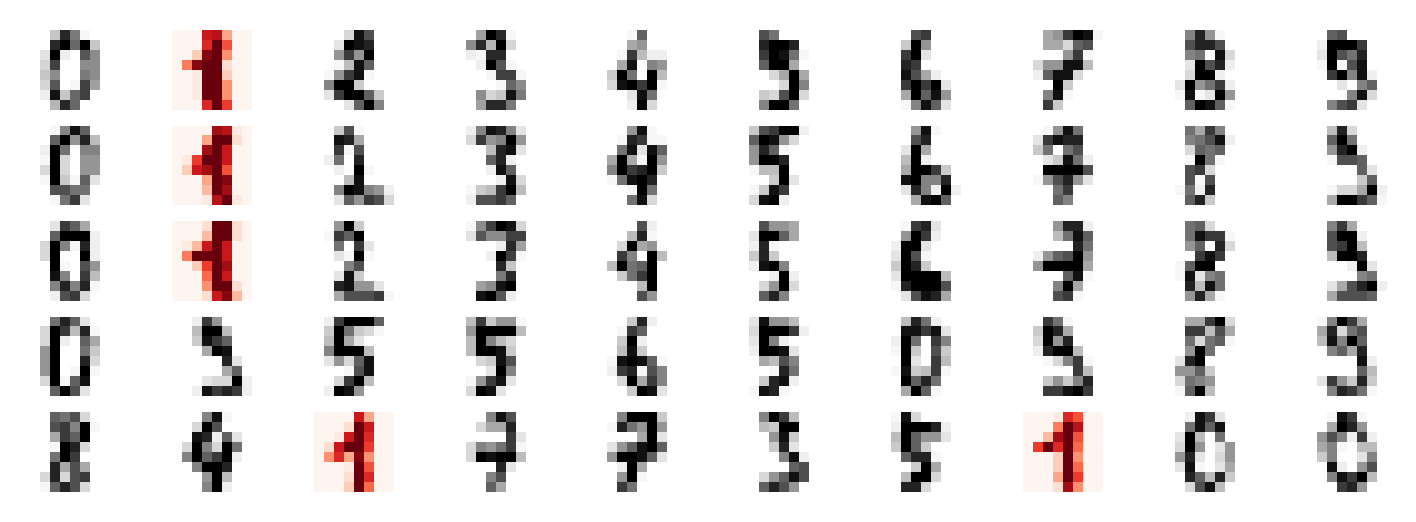

In [2]:
# Train the neural network ensemble.

import numpy as np

from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neural_network import MLPClassifier

cv = KFold(n_splits=5, shuffle=True)
nn = MLPClassifier(hidden_layer_sizes=(100, 100))
nne = BaggingClassifier(estimator=nn, n_jobs=-1)
acc = np.mean(cross_val_score(nne, X, y, cv=cv, scoring='accuracy', n_jobs=-1))
print(f"Validation Accuracy: {acc:.2%}")

# Show which digits it identifies as 1 (shown in red).

nne.fit(X, y)
nne.predict = lambda X: nne.predict_proba(X)[:, 1] # overwrite the default predict
p = nne.predict(X)

fig, axs = plt.subplots(ncols=10, nrows=5, figsize=(6, 2))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(X[i].reshape(8, 8), cmap='Greys' if p[i] < 0.5 else 'Reds')
    ax.axis('off')

## Local Interpretable Model-Agnostic Explanations (LIME)

Let's first build a LIME explanation. To do that, we first pick an input we want to explain. Next, we perturb it slightly (local changes).

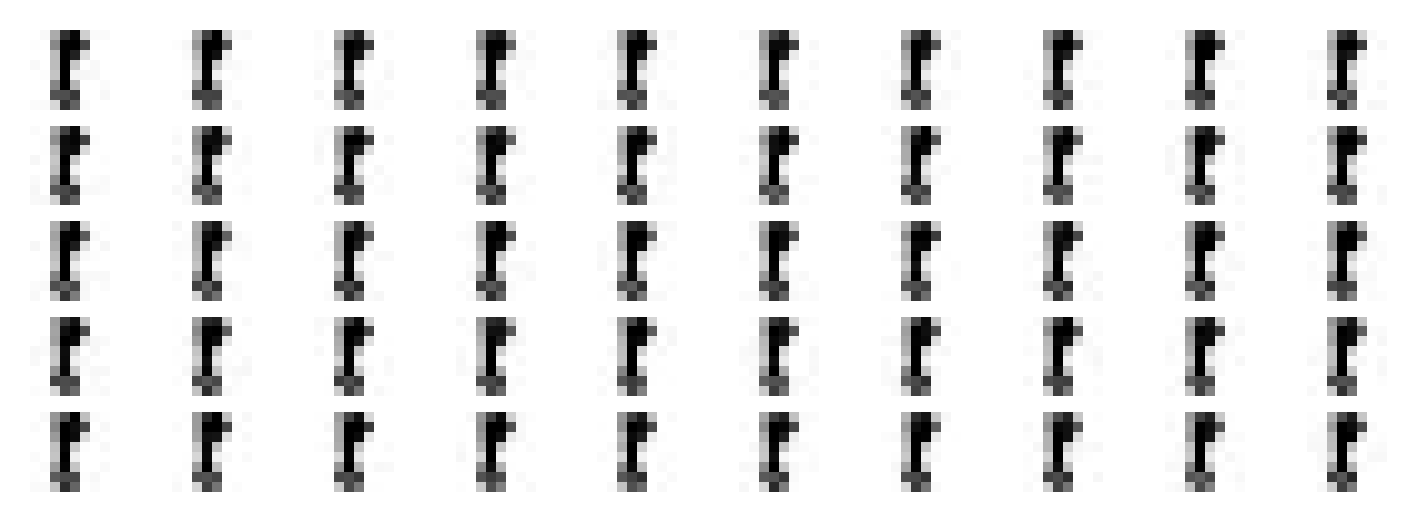

In [3]:
X_local = X[129]
X_sample = X_local + np.random.uniform(
    low=-1, high=+1, size=(10000, len(X_local)))
X_sample = np.maximum(X_sample, 0)
X_sample = np.minimum(X_sample, 16)

fig, axs = plt.subplots(ncols=10, nrows=5, figsize=(6, 2))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(X_sample[i].reshape(8, 8), cmap='Greys')
    ax.axis('off')

Next, we approximate the predicted probability of being 1 with a linear model. Evidently, the linear model is a decent approximation to the complex model, at least locally.

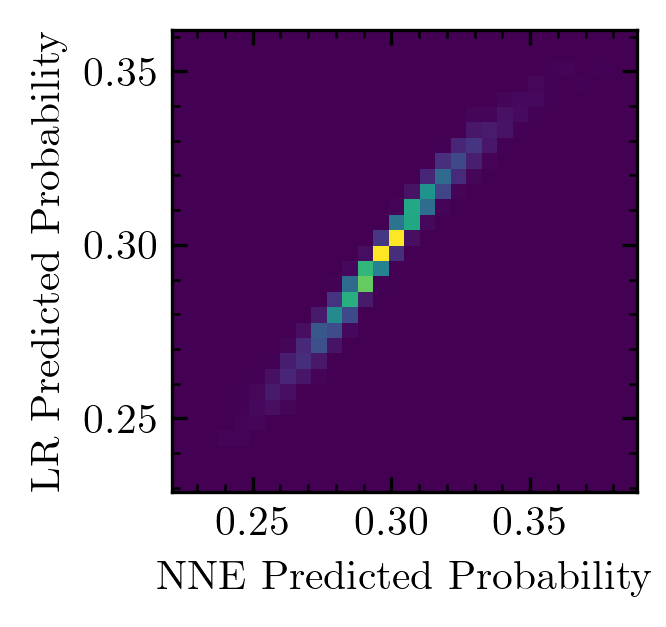

In [4]:
from sklearn.linear_model import LinearRegression

p_pred = nne.predict(X_sample)
lr = LinearRegression().fit(X_sample, p_pred)
p_pred_lin = lr.predict(X_sample)

plt.figure(figsize=(2, 2))
plt.hist2d(p_pred, p_pred_lin, bins=30)
plt.xlabel('NNE Predicted Probability')
plt.ylabel('LR Predicted Probability');

Next, we can interpret the linear model, i.e., its coefficients.

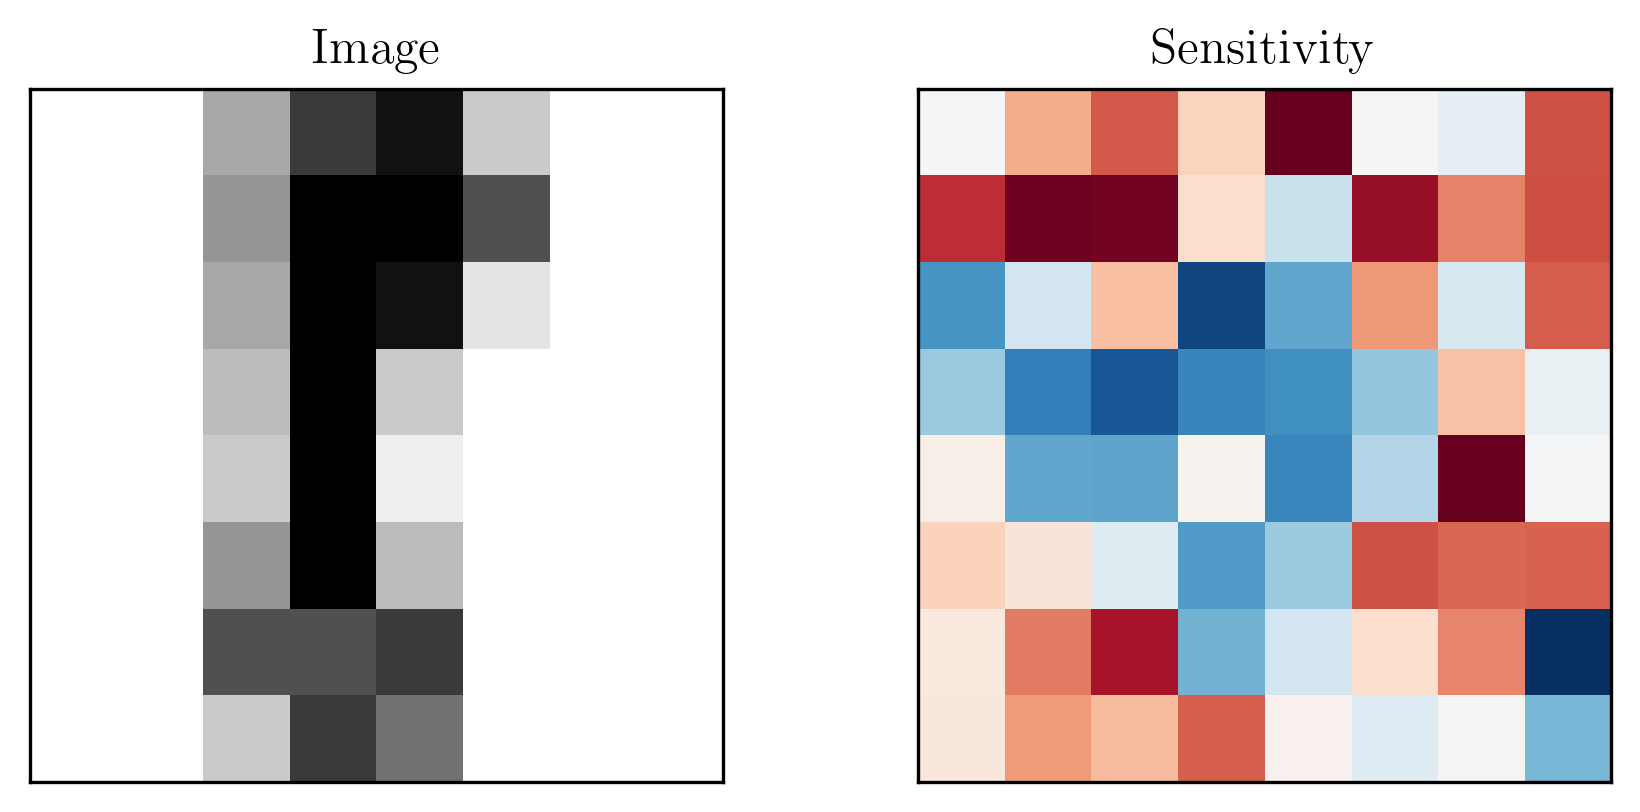

In [5]:
fig, axs = plt.subplots(ncols=2, figsize=(7, 3))
axs[0].imshow(X_local.reshape(8, 8), cmap='Greys')
axs[0].set_title('Image')
axs[1].imshow(lr.coef_.reshape(8, 8), vmin=-0.01, vmax=+0.01, cmap='RdBu')
axs[1].set_title('Sensitivity')
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

To double-check the method, let's create a data set where the AI can "cheat". We artificially encode whether the number is 1 into the first pixel (upper left corner).

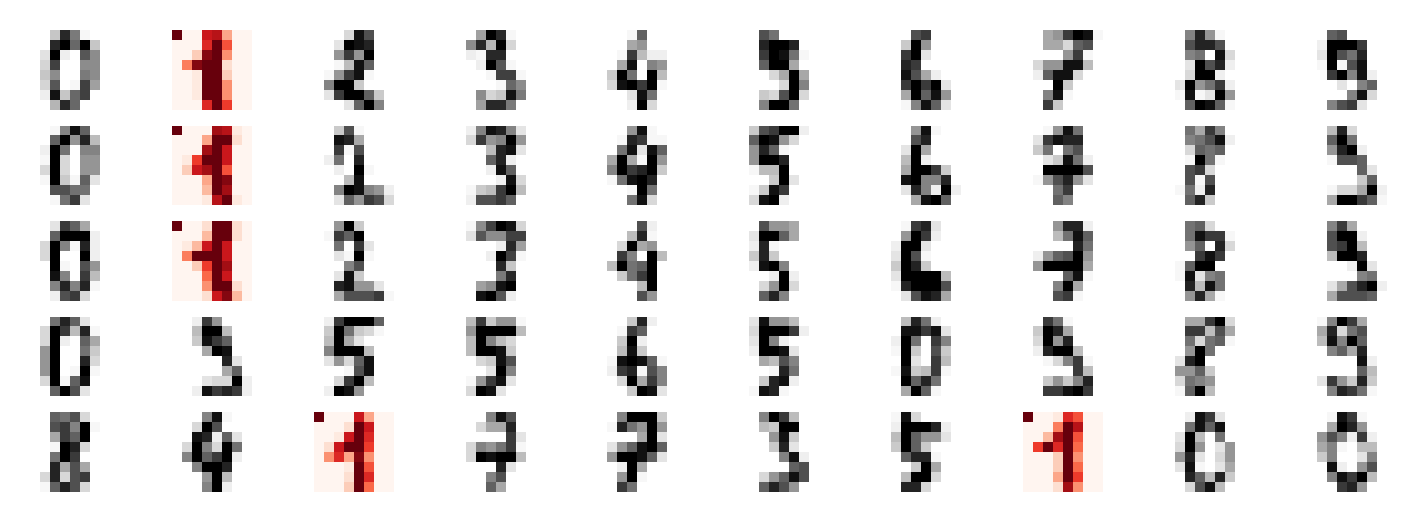

In [6]:
X_cheat = X.copy()
X_cheat[:, 0] = y * 16
nne_cheat = BaggingClassifier(estimator=nn, n_jobs=-1)
nne_cheat.fit(X_cheat, y)
nne_cheat.predict = lambda X: nne_cheat.predict_proba(X)[:, 1]
p = nne_cheat.predict(X_cheat)

fig, axs = plt.subplots(ncols=10, nrows=5, figsize=(6, 2))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(X_cheat[i].reshape(8, 8), cmap='Greys' if p[i] < 0.5 else 'Reds')
    ax.axis('off')

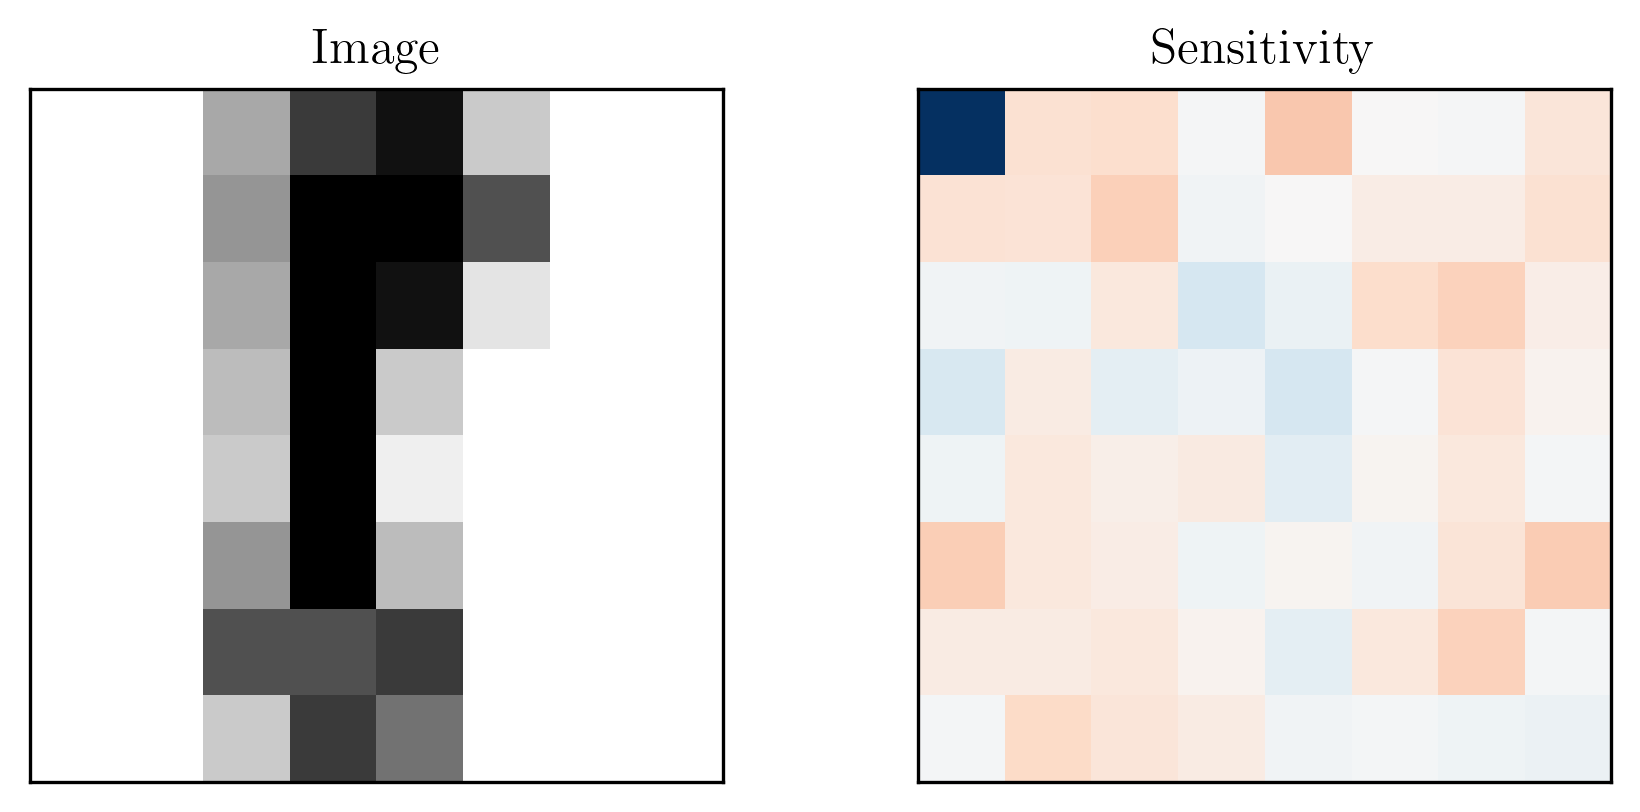

In [7]:
X_local = X_cheat[129]
X_sample = X_local + np.random.uniform(
    low=-1, high=+1, size=(10000, len(X_local)))
X_sample = np.maximum(X_sample, 0)
X_sample = np.minimum(X_sample, 16)

p_pred = nne_cheat.predict_proba(X_sample)[:, 1]
lr = LinearRegression().fit(X_sample, p_pred)
p_pred_lin = lr.predict(X_sample)

fig, axs = plt.subplots(ncols=2, figsize=(7, 3))
axs[0].imshow(X_local.reshape(8, 8), cmap='Greys')
axs[0].set_title('Image')
axs[1].imshow(lr.coef_.reshape(8, 8), vmin=-0.005, vmax=+0.005, cmap='RdBu')
axs[1].set_title('Sensitivity')
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

## Shapley Values

In [8]:
def compute_shapley_values(X_target, X_bkg, model, n_mc=100):
    """Compute approximate shapley sampling values.

    Parameters
    ----------
    X_target : numpy.ndarray
        Target samples for which to compute Shapley values.
    X_bkg : numpy.ndarray
        Samples used as background in the Monte-Carlo simulation.
    model : object
        Model that has a `predict_proba` function for which we compute the
        Shapley values.
    n : n_mc
        Number of Monte-Carlo simulation. One Monte-Carlo simulations includes
        one random realization of the background and the order for each of the
        target samples.

    Returns
    -------
    shap : numpy.ndarray
        Shapley values. Has the same shape as ``X_target.``

    """
    n_samples, n_feat = X_target.shape
    shap = np.zeros((n_samples, n_feat))

    for k in range(n_mc):
        X = X_bkg[np.random.choice(len(X_bkg), size=len(X_target))]
        perm = np.random.permutation(n_feat)
        pred_old = model.predict(X)
        for feature in perm:
            X[:, feature] = X_target[:, feature]
            pred_new = model.predict(X)
            shap[:, feature] += (pred_new - pred_old) / n_mc
            pred_old = pred_new

    return shap

shap = compute_shapley_values(X, X, nne, n_mc=300)

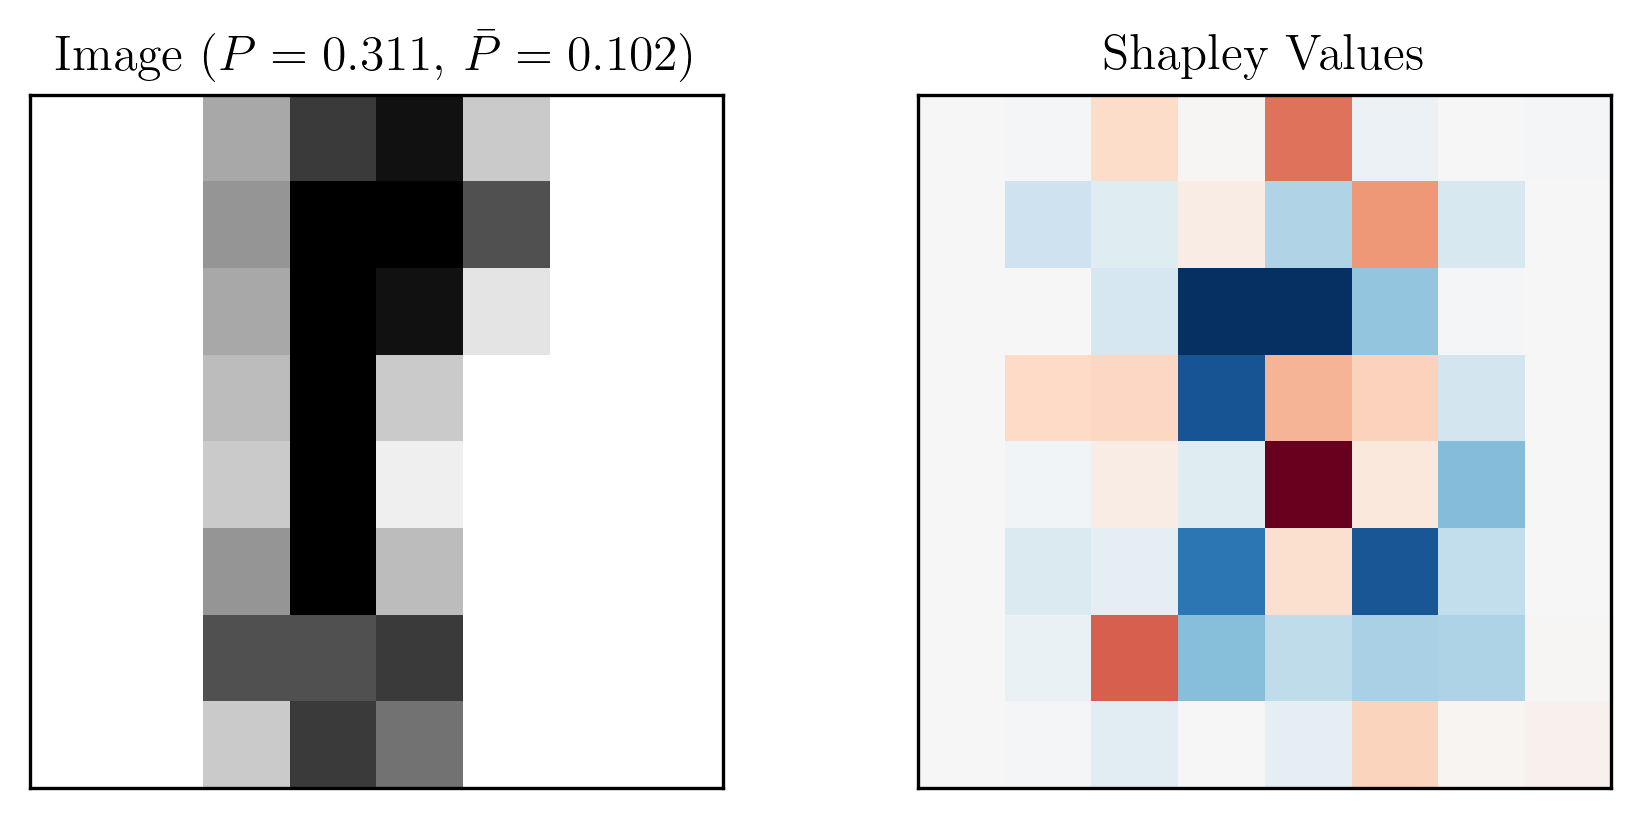

In [9]:
p = nne.predict(X)

fig, axs = plt.subplots(ncols=2, figsize=(7, 3))
axs[0].imshow(X[129].reshape(8, 8), cmap='Greys')
axs[0].set_title(rf'Image ($P={p[129]:.3f}$, $\bar P = {np.mean(p):.3f}$)')
axs[1].imshow(shap[129].reshape(8, 8), vmin=-0.05, vmax=+0.05, cmap='RdBu')
axs[1].set_title('Shapley Values')
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

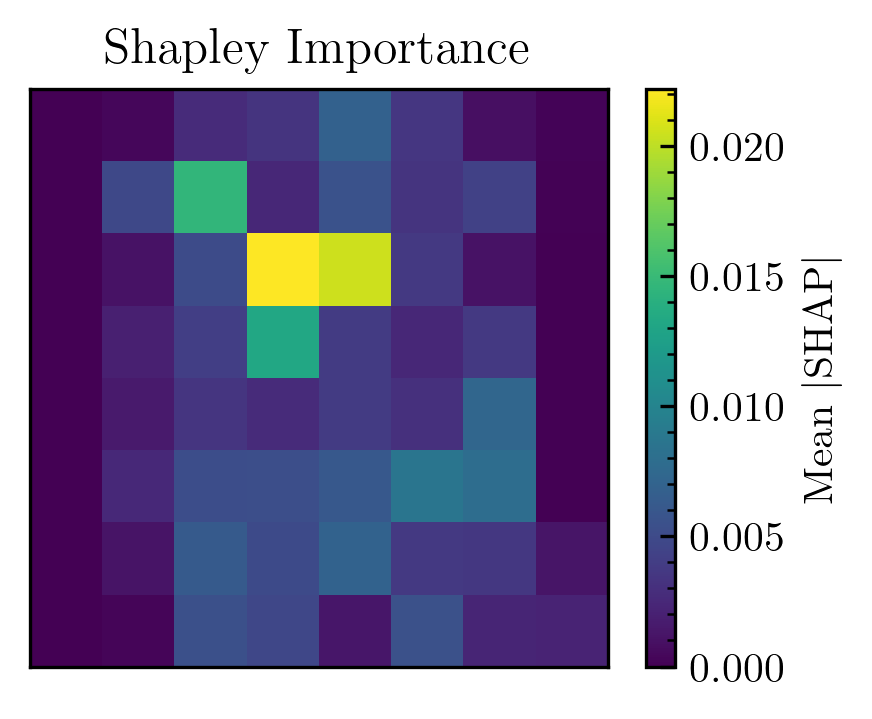

In [10]:
plt.imshow(np.mean(np.abs(shap), axis=0).reshape(8, 8), vmin=0)
plt.xticks([])
plt.yticks([])
plt.colorbar(label='Mean $|$SHAP$|$')
plt.title('Shapley Importance');